In [1]:
#import streamlit as st
#import pandas as pd
#import altair as alt
#import plotly.express as px

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mtick
import os
import platform
import glob
import platform

In [4]:
import getpass

# Obtener el nombre de usuario actual
user = getpass.getuser()

if platform.system() == 'Darwin':
    
    if user == 'juliandiazparra':  # Usuario en el primer Mac
        os.chdir(
            '/Users/juliandiazparra/Library/CloudStorage/GoogleDrive-julian.adiaz@hotmail.com/Mi unidad/Negocios/Familiar/GIGANAV')
        
    elif user == 'usuarioo':  # Nombre del usuario en el segundo Mac
        os.chdir(
            '/Users/usuarioo/Library/CloudStorage/GoogleDrive-julian.adiaz@hotmail.com/Mi unidad/Negocios/Familiar/GIGANAV')

# Definir las rutas como antes
folder = os.getcwd()
data = os.path.join(folder, 'Datos')
provisiones = os.path.join(data, 'Provisiones')
facturas = os.path.join(data, 'Facturas')
tickets = os.path.join(data, 'Tickets')
usuarios = os.path.join(data, 'Usuarios')
egresos = os.path.join(data, 'Egresos')
transacciones = os.path.join(data, 'Transacciones')
analisis = os.path.join(folder, 'Operacion/Analisis')
resultados = os.path.join(analisis, 'Resultados')
bases = os.path.join(analisis, 'Bases_analisis')
outputs = os.path.join(analisis, 'Outputs')
plots = os.path.join(outputs, 'Gráficos')
usuarios_clean = os.path.join(bases, 'Usuarios')
transac_clean = os.path.join(bases, 'Transacciones')
tickets_clean = os.path.join(bases, 'Tickets')
facturas_clean = os.path.join(bases, 'Facturas')
egresos_clean = os.path.join(bases, 'Egresos')
working = os.path.join(bases, 'Bases_trabajo')
codigo = os.path.join(folder, 'Operacion/Analisis/Código')
conciliaciones = os.path.join(folder, 'Operacion/Operativo/Administrativo/Conciliaciones')

## Importación base de trabajo

In [5]:
list_of_files = glob.glob(os.path.join(outputs,'Resumen_mes_categorias*.csv'))
latest_file = max(list_of_files, key=os.path.getctime)
working_summary=pd.read_csv(latest_file, low_memory=False)
working_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 69 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Unnamed: 0                                  34 non-null     int64  
 1   mes_crd                                     34 non-null     object 
 2   tiempo_respuesta_instal_fibra               34 non-null     float64
 3   tiempo_respuesta_instal_radio               24 non-null     float64
 4   tiempo_respuesta_retiro_fibra               34 non-null     float64
 5   tiempo_respuesta_soporte_fibra              34 non-null     float64
 6   tiempo_respuesta_soporte_radio              34 non-null     float64
 7   tiempo_respuesta_traslado_fibra             34 non-null     float64
 8   tiempo_respuesta_traslado_radio             8 non-null      float64
 9   tiempo_respuesta_retiro_radio               4 non-null      float64
 10  tiempo_respuesta

In [6]:
list_of_files = glob.glob(os.path.join(outputs,'Base_tickets*.csv'))
latest_file = max(list_of_files, key=os.path.getctime)
working_data=pd.read_csv(latest_file, low_memory=False)
working_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16876 entries, 0 to 16875
Data columns (total 60 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_ticket              16876 non-null  int64  
 1   nombre                 16876 non-null  object 
 2   asunto                 16876 non-null  object 
 3   tecnico                16876 non-null  object 
 4   zona                   16832 non-null  object 
 5   abierto_por            16876 non-null  object 
 6   departamento           16876 non-null  object 
 7   categoria              16758 non-null  object 
 8   subcategoria           5567 non-null   object 
 9   fecha_abierto          16876 non-null  object 
 10  fecha_visita           16850 non-null  object 
 11  fecha_cerrado          16876 non-null  object 
 12  mes_crd                16876 non-null  object 
 13  first_day              16876 non-null  object 
 14  tiempo_resolucion      16876 non-null  object 
 15  ti

## Analisis fibra vs radio

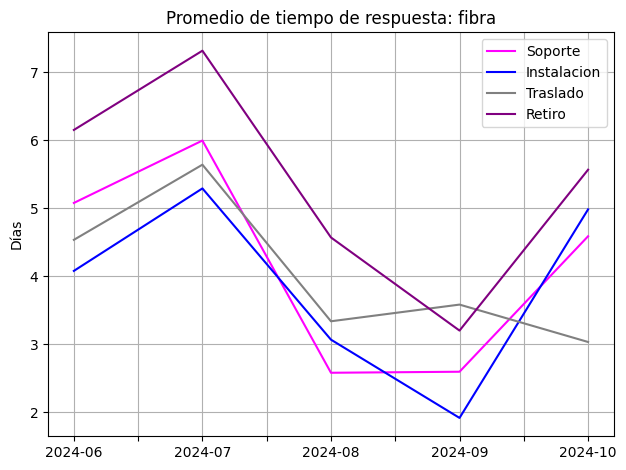

In [8]:
fig, ax= plt.subplots()

working_summary.iloc[-5:].plot(x='mes_crd', y='tiempo_respuesta_soporte_fibra', 
                               kind='line', ax=ax, 
                               color='magenta', grid=True)
working_summary.iloc[-5:].plot(x='mes_crd', y='tiempo_respuesta_instal_fibra', 
                             kind='line', ax=ax, 
                               color='blue', grid=True)
working_summary.iloc[-5:].plot(x='mes_crd', y='tiempo_respuesta_traslado_fibra', 
                             kind='line', ax=ax, 
                               color='grey', grid=True)
working_summary.iloc[-5:].plot(x='mes_crd', y='tiempo_respuesta_retiro_fibra', 
                             kind='line', ax=ax, 
                               color='purple', grid=True)


plt.setp(ax, ylabel='Días', xlabel='', title='Promedio de tiempo de respuesta: fibra')
ax.legend(['Soporte', 'Instalacion', 'Traslado','Retiro'])
plt.tight_layout()
plt.show()

In [10]:
mask_tecnico=working_data['categoria'].isin(['instal','soporte','retiro','traslado'])

In [12]:
summary_tix_fibra_radio=working_data.loc[
    mask_tecnico].groupby(
    ['mes_crd', 'tecnologia']).agg(
    num_tix=('id_ticket','nunique')).reset_index().pivot(
    columns='tecnologia',
    values='num_tix', 
    index='mes_crd').reset_index()
summary_tix_fibra_radio.columns=['mes_crd','fibra','radio']
summary_tix_fibra_radio.loc[
    :,'porc_fibra'
]=summary_tix_fibra_radio[
    'fibra']/(summary_tix_fibra_radio[
    'fibra']+summary_tix_fibra_radio[
    'radio'])

summary_tix_fibra_radio.loc[
    :,'porc_radio'
]=summary_tix_fibra_radio[
    'radio']/(summary_tix_fibra_radio[
    'fibra']+summary_tix_fibra_radio[
    'radio'])
summary_tix_fibra_radio.tail()
#print('Durante el último trimestre, el '+str(
#    summary_tix_fibra_radio.iloc[-4:-1][
#        'porc_fibra'].mean())+' de tickets fueron de fibra')

,mes_crd,fibra,radio,porc_fibra,porc_radio
29,2024-06,416,7,0.983452,0.016548
30,2024-07,463,10,0.978858,0.021142
31,2024-08,459,16,0.966316,0.033684
32,2024-09,713,15,0.979396,0.020604
33,2024-10,379,7,0.981865,0.018135


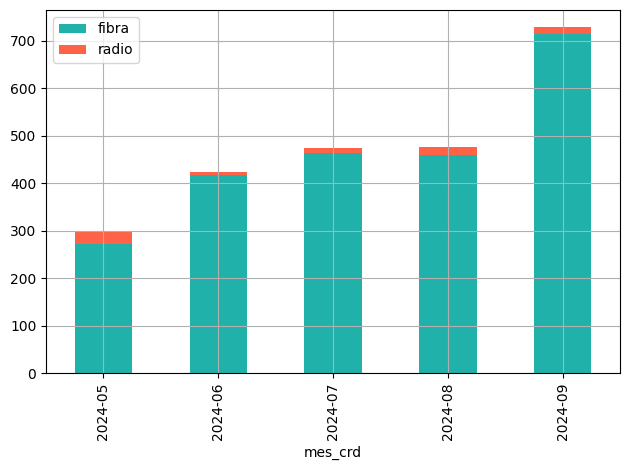

In [13]:
fig,ax=plt.subplots()
summary_tix_fibra_radio.iloc[-6:-1,:3].plot.bar(
    'mes_crd','fibra',
    ax=ax, #bottom=base, 
    color='lightseagreen', 
    grid=True)
summary_tix_fibra_radio.iloc[-6:-1,:3].plot.bar(
    'mes_crd','radio',
    ax=ax, bottom=summary_tix_fibra_radio.iloc[-6:-1,:3]['fibra'], 
    color='tomato', 
    grid=True)

plt.tight_layout()
plt.show()

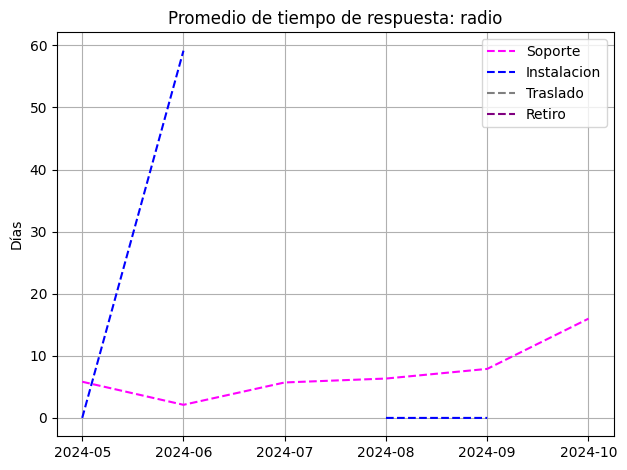

In [14]:
fig, ax=plt.subplots()

working_summary.iloc[-6:].plot(
    x='mes_crd', y='tiempo_respuesta_soporte_radio', 
    kind='line', ax=ax, 
    color='magenta', grid=True, linestyle='--')

working_summary.iloc[-6:].plot(
    x='mes_crd', y='tiempo_respuesta_instal_radio', 
                               kind='line', ax=ax, 
                               color='blue', grid=True, linestyle='--')

working_summary.iloc[-6:].plot(
    x='mes_crd', y='tiempo_respuesta_traslado_radio', 
                               kind='line', ax=ax, 
                               color='grey', grid=True, linestyle='--')

working_summary.iloc[-6:].plot(
    x='mes_crd', y='tiempo_respuesta_retiro_radio', 
                               kind='line', ax=ax, 
                               color='purple', grid=True, linestyle='--')

plt.setp(ax, ylabel='Días', xlabel='', title='Promedio de tiempo de respuesta: radio')
ax.legend(['Soporte', 'Instalacion', 'Traslado','Retiro'])
plt.tight_layout()
plt.show()